# 🔬 Unified Experiment Analysis Workbench (`ANALYSIS.ipynb`)

Welcome to the central analysis workbench for Alzheimer's disease progression modeling and multi-task 3D ResNet-18 classification.

---
### 🛠️ How to Add a New Experiment for Analysis:
To analyze a new experiment (or new model variant/directory), simply add an entry to the `EXPERIMENT_REGISTRY` dictionary in **Cell 2**:

```python
EXPERIMENT_REGISTRY['My_New_Model'] = {
    'name': '4. My New Experiment Name',
    'path': '/path/to/my_predictions.csv',
    'description': 'Brief description of model architecture or parameters'
}
```

---
### 📊 Currently Registered Experiments:
1. **`sustain_guided`**: Baseline SuStaIn-guided 3D ResNet-18 (Subtype & Stage prediction heads)
2. **`mlp_bridge`**: 2-Layer MLP Bridge mapping SuStaIn subtype & stage predictions to 4-class diagnosis (`CN`, `sMCI`, `pMCI`, `AD`)
3. **`resnet18_4head`**: End-to-end 4-Head 3D ResNet-18 (Subtype, Stage & 4-Class Diagnosis heads trained multi-task)

---
### 📚 Notebook Sections:
- **1. Setup & Experiment Registry Data Loader**
- **2. Quantitative Performance Leaderboard** (Accuracy, Macro F1, Kappa, Stage MAE, Correlation)
- **3. Trajectory Visualizations (All Experiments - 3 Versions Each)**:
  - **Version 1**: Ground Truth SuStaIn Subtype & Stage with True Diagnosis Label
  - **Version 2**: Model Predicted Subtype & Stage with True Diagnosis Label
  - **Version 3**: Completely Model Predicted (Model Subtype, Stage & Diagnosis)
- **4. Faceted Subtype Distribution Grids** (3x2 Subtype-separated grids for all experiments)
- **5. Fold-by-Fold Cross-Validation Trajectory Analysis** (Fold breakdowns for all experiments)
- **6. Cross-Experiment Diagnosis Confusion Matrices**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    cohen_kappa_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error
)
from scipy.stats import spearmanr, pearsonr

# Set theme matching project standards
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18
})

# Clinical color palette matching paper conventions
PALETTE = {
    'CN': '#2ca02c',    # Green
    'sMCI': '#1f77b4',  # Blue
    'pMCI': '#ff7f0e',  # Orange
    'AD': '#d62728',     # Red
    'Unknown': '#7f7f7f'
}

LABEL_ORDER = ['CN', 'sMCI', 'pMCI', 'AD']

print("✓ Environment initialized successfully.")

✓ Environment initialized successfully.


## 1. Experiment Registry & Standardized Data Loader

In [2]:
# -------------------------------------------------------------------
# EXPERIMENT REGISTRY: Easily add new experiment directories/CSVs here!
# -------------------------------------------------------------------
EXPERIMENT_REGISTRY = {
    'sustain_guided': {
        'name': '1. SuStaIn-Guided ResNet-18 (Baseline)',
        'path': '/Users/khoale/Downloads/Alzheimer_Code/sustain_guided_predictions.csv',
        'description': '3D ResNet-18 predicting SuStaIn Subtype & Stage'
    },
    'mlp_bridge': {
        'name': '2. MLP Bridge (Subtype/Stage -> Diagnosis)',
        'path': '/Users/khoale/Downloads/Alzheimer_Code/outputs/mlp_bridge_4class_predictions.csv',
        'description': '2-Layer MLP converting SuStaIn predictions to 4-class diagnosis'
    },
    'resnet18_4head': {
        'name': '3. 4-Head ResNet-18 (Multi-Task Combined)',
        'path': '/Users/khoale/Downloads/Alzheimer_Code/sustain_4head_resnet18_predictions.csv',
        'description': 'End-to-end multi-task 3D ResNet-18 for Subtype, Stage & Diagnosis'
    }
}

# Reference CSV for merging ground truth clinical labels if absent in an experiment
LABEL_REF_CSV = '/Users/khoale/Downloads/Alzheimer_Code/sustain_subject_staging_results.csv'
label_ref_df = None
if os.path.exists(LABEL_REF_CSV):
    df_ref_raw = pd.read_csv(LABEL_REF_CSV)
    if 'PTID' in df_ref_raw.columns and 'Label' in df_ref_raw.columns:
        label_ref_df = df_ref_raw[['PTID', 'Label']].drop_duplicates(subset=['PTID'])

def load_experiment_data(exp_key):
    """
    Loads and standardizes an experiment predictions CSV.
    Standardizes column names to: Label_True, Label_Pred (if present),
    Assigned_Subtype_True, Assigned_Subtype_Pred, Assigned_Stage_True, Assigned_Stage_Pred.
    """
    if exp_key not in EXPERIMENT_REGISTRY:
        raise KeyError(f"Experiment '{exp_key}' not found in EXPERIMENT_REGISTRY.")
        
    cfg = EXPERIMENT_REGISTRY[exp_key]
    csv_path = cfg['path']
    if not os.path.exists(csv_path):
        print(f"Warning: File not found for '{exp_key}' at {csv_path}")
        return None
        
    df = pd.read_csv(csv_path)
    
    # Standardize Ground Truth Diagnosis Label column name
    if 'Label_True' not in df.columns:
        if 'Label' in df.columns:
            df['Label_True'] = df['Label']
        elif label_ref_df is not None:
            df = df.merge(label_ref_df, on='PTID', how='left')
            df['Label_True'] = df['Label']
        else:
            df['Label_True'] = 'Unknown'
            
    # Handle Label_Pred fallback
    if 'Label_Pred' not in df.columns:
        df['Label_Pred'] = None
        
    return df

# Load all registered experiments
experiments_data = {}
print("--- Loaded Experiments Summary ---")
for key in EXPERIMENT_REGISTRY:
    data = load_experiment_data(key)
    if data is not None:
        experiments_data[key] = data
        n_diag = data['Label_Pred'].notna().sum()
        exp_name_str = EXPERIMENT_REGISTRY[key]['name']
        print(f"  • [{key}] '{exp_name_str}': {len(data)} subjects, {n_diag} diagnosis predictions")


--- Loaded Experiments Summary ---
  • [sustain_guided] '1. SuStaIn-Guided ResNet-18 (Baseline)': 577 subjects, 0 diagnosis predictions
  • [mlp_bridge] '2. MLP Bridge (Subtype/Stage -> Diagnosis)': 577 subjects, 577 diagnosis predictions
  • [resnet18_4head] '3. 4-Head ResNet-18 (Multi-Task Combined)': 577 subjects, 577 diagnosis predictions


## 2. Quantitative Performance Leaderboard

In [3]:
leaderboard_rows = []

for key, df in experiments_data.items():
    exp_name = EXPERIMENT_REGISTRY[key]['name']
    
    # 1. Clinical Diagnosis Head Metrics
    has_diag = df['Label_Pred'].notna().any()
    if has_diag:
        valid_mask = df['Label_Pred'].notna() & df['Label_True'].notna()
        yt = df.loc[valid_mask, 'Label_True']
        yp = df.loc[valid_mask, 'Label_Pred']
        
        diag_acc = accuracy_score(yt, yp)
        diag_b_acc = balanced_accuracy_score(yt, yp)
        diag_macro_f1 = f1_score(yt, yp, average='macro')
        diag_kappa = cohen_kappa_score(yt, yp)
    else:
        diag_acc, diag_b_acc, diag_macro_f1, diag_kappa = np.nan, np.nan, np.nan, np.nan
        
    # 2. Subtype Prediction Metrics
    if 'Assigned_Subtype_True' in df.columns and 'Assigned_Subtype_Pred' in df.columns:
        yt_sub = df['Assigned_Subtype_True'].astype(int)
        yp_sub = df['Assigned_Subtype_Pred'].astype(int)
        sub_acc = accuracy_score(yt_sub, yp_sub)
        sub_f1 = f1_score(yt_sub, yp_sub, average='macro')
    else:
        sub_acc, sub_f1 = np.nan, np.nan
        
    # 3. Stage Prediction Metrics
    if 'Assigned_Stage_True' in df.columns and 'Assigned_Stage_Pred' in df.columns:
        yt_stg = df['Assigned_Stage_True']
        yp_stg = df['Assigned_Stage_Pred']
        stg_mae = mean_absolute_error(yt_stg, yp_stg)
        stg_rmse = np.sqrt(mean_squared_error(yt_stg, yp_stg))
        stg_r, _ = pearsonr(yt_stg, yp_stg)
    else:
        stg_mae, stg_rmse, stg_r = np.nan, np.nan, np.nan
        
    leaderboard_rows.append({
        'Experiment Key': key,
        'Experiment Name': exp_name,
        'Diag Acc (%)': f"{diag_acc*100:.2f}%" if pd.notna(diag_acc) else "N/A",
        'Diag Macro F1': f"{diag_macro_f1:.4f}" if pd.notna(diag_macro_f1) else "N/A",
        'Diag Kappa': f"{diag_kappa:.4f}" if pd.notna(diag_kappa) else "N/A",
        'Subtype Acc (%)': f"{sub_acc*100:.2f}%" if pd.notna(sub_acc) else "N/A",
        'Subtype Macro F1': f"{sub_f1:.4f}" if pd.notna(sub_f1) else "N/A",
        'Stage MAE': f"{stg_mae:.3f}" if pd.notna(stg_mae) else "N/A",
        'Stage Pearson r': f"{stg_r:.3f}" if pd.notna(stg_r) else "N/A"
    })

leaderboard_df = pd.DataFrame(leaderboard_rows)
print('=' * 105)
print('                                CROSS-EXPERIMENT PERFORMANCE LEADERBOARD                                 ')
print('=' * 105)
display(leaderboard_df)


                                CROSS-EXPERIMENT PERFORMANCE LEADERBOARD                                 


,Experiment Key,Experiment Name,Diag Acc (%),Diag Macro F1,Diag Kappa,Subtype Acc (%),Subtype Macro F1,Stage MAE,Stage Pearson r
0,sustain_guided,1. SuStaIn-Guided ResNet-18 (Baseline),N/A,N/A,N/A,68.11%,0.6632,5.270,0.646
1,mlp_bridge,2. MLP Bridge (Subtype/Stage -> Diagnosis),44.19%,0.3940,0.2370,68.11%,0.6632,5.270,0.646
2,resnet18_4head,3. 4-Head ResNet-18 (Multi-Task Combined),53.55%,0.3821,0.3407,57.89%,0.4482,6.273,0.534


## 3. Trajectory Visualizations (All Experiments)

In [4]:
def plot_experiment_trajectories(exp_key):
    """
    Plots the 3 requested versions of trajectory distributions directly in the notebook:
      Version 1: Ground Truth SuStaIn (Subtype GT & Stage GT + True Diagnosis)
      Version 2: Model Predicted Subtype & Stage + True Diagnosis
      Version 3: Completely Model Predicted (Model Subtype & Stage + Model Diagnosis)
    """
    df = experiments_data.get(exp_key)
    if df is None:
        print(f"Error: No data available for experiment '{exp_key}'")
        return
        
    exp_name = EXPERIMENT_REGISTRY.get(exp_key, {}).get('name', exp_key)
    
    def plot_single(subtype_col, stage_col, label_col, title):
        fig, ax = plt.subplots(figsize=(14, 7.5))
        
        rng = np.random.default_rng(42)
        df_p = df.copy()
        df_p['Subtype_Jittered'] = df_p[subtype_col].astype(float) + rng.normal(loc=0.0, scale=0.08, size=len(df_p))
        
        for st in [1.0, 2.0, 3.0]:
            ax.axhline(y=st, color='gray', linestyle='--', alpha=0.3, zorder=1)
            
        sns.scatterplot(
            data=df_p,
            x=stage_col,
            y='Subtype_Jittered',
            hue=label_col,
            hue_order=LABEL_ORDER,
            palette=PALETTE,
            alpha=0.8,
            s=70,
            edgecolor='w',
            linewidth=0.5,
            ax=ax,
            zorder=2
        )
        
        ax.set_title(f"{exp_name}\n{title}", pad=15, weight='bold')
        ax.set_xlabel('Assigned Progression Stage (0 to 48)', labelpad=10)
        ax.set_ylabel('Assigned Subtype Trajectory', labelpad=10)
        ax.set_yticks([1.0, 2.0, 3.0])
        ax.set_yticklabels(['Subtype 1', 'Subtype 2', 'Subtype 3'])
        ax.set_ylim(0.6, 3.4)
        ax.set_xlim(-1, 49)
        ax.legend(title='Diagnosis', loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=True, shadow=True)
        
        # Statistics annotation box on right side
        stats_text = f"Subtype Breakdown ({label_col}):\n"
        for sub in [1.0, 2.0, 3.0]:
            sub_df = df_p[df_p[subtype_col] == sub]
            total_sub = len(sub_df)
            stats_text += f"\nSubtype {int(sub)} (N={total_sub}):\n"
            if total_sub > 0:
                counts = sub_df[label_col].value_counts()
                for lbl in LABEL_ORDER:
                    if lbl in counts:
                        cnt = counts[lbl]
                        pct = (cnt / total_sub) * 100
                        stats_text += f"  - {lbl}: {cnt} ({pct:.1f}%)\n"
                        
        fig.text(0.77, 0.15, stats_text, fontsize=9.5, family='monospace', verticalalignment='bottom',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))
        
        plt.subplots_adjust(right=0.75, left=0.08, top=0.90, bottom=0.1)
        plt.show()

    # Version 1: Ground Truth
    plot_single('Assigned_Subtype_True', 'Assigned_Stage_True', 'Label_True', 
                'Version 1: Ground Truth SuStaIn Trajectory with True Diagnosis')
    
    # Version 2: Model Stage/Subtype + True Diagnosis
    plot_single('Assigned_Subtype_Pred', 'Assigned_Stage_Pred', 'Label_True', 
                'Version 2: Model Predicted Subtype & Stage with True Diagnosis')
    
    # Version 3: Completely Model Predicted
    if df['Label_Pred'].notna().any():
        plot_single('Assigned_Subtype_Pred', 'Assigned_Stage_Pred', 'Label_Pred', 
                    'Version 3: Completely Model Predicted (Model Subtype, Stage & Diagnosis)')
    else:
        print(f"Note: Skipping Version 3 for '{exp_key}' (No Label_Pred diagnosis prediction column).")



  TRAJECTORY PLOTS: 1. SuStaIn-Guided ResNet-18 (Baseline)


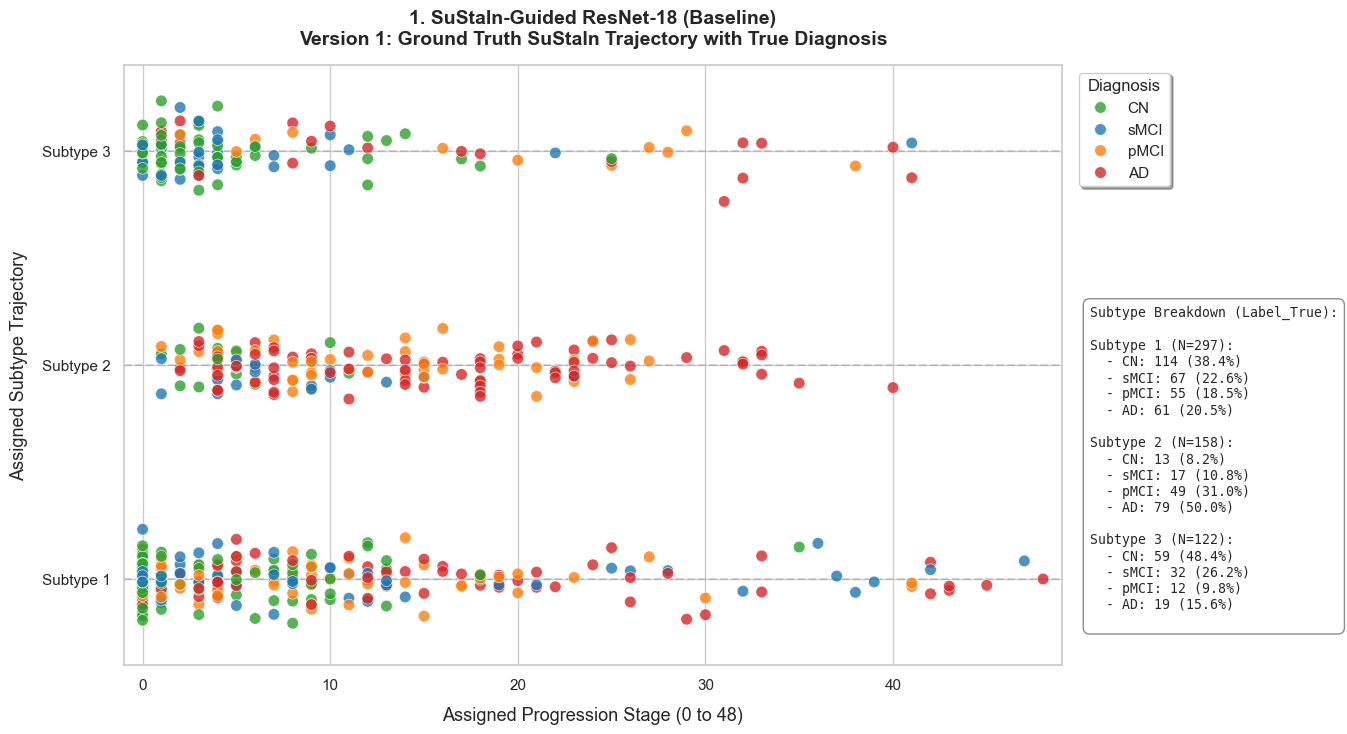

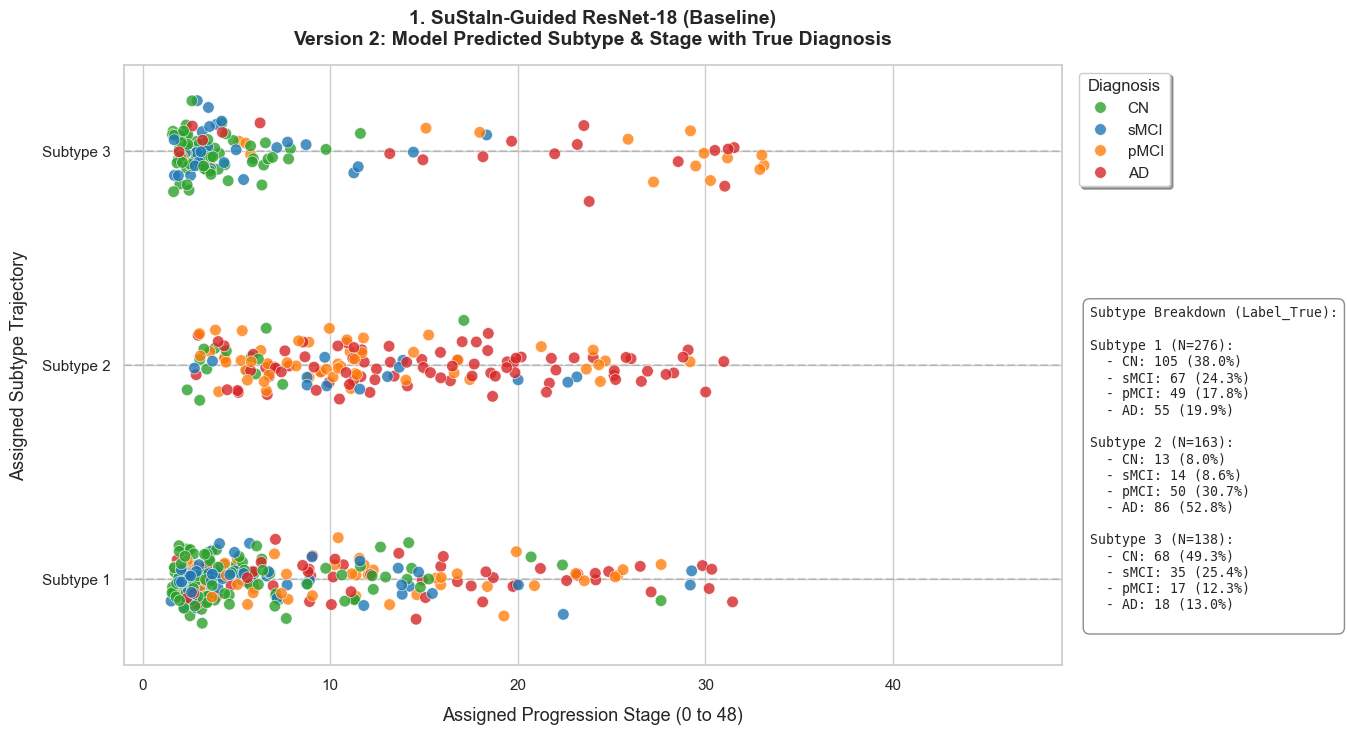

Note: Skipping Version 3 for 'sustain_guided' (No Label_Pred diagnosis prediction column).

  TRAJECTORY PLOTS: 2. MLP Bridge (Subtype/Stage -> Diagnosis)


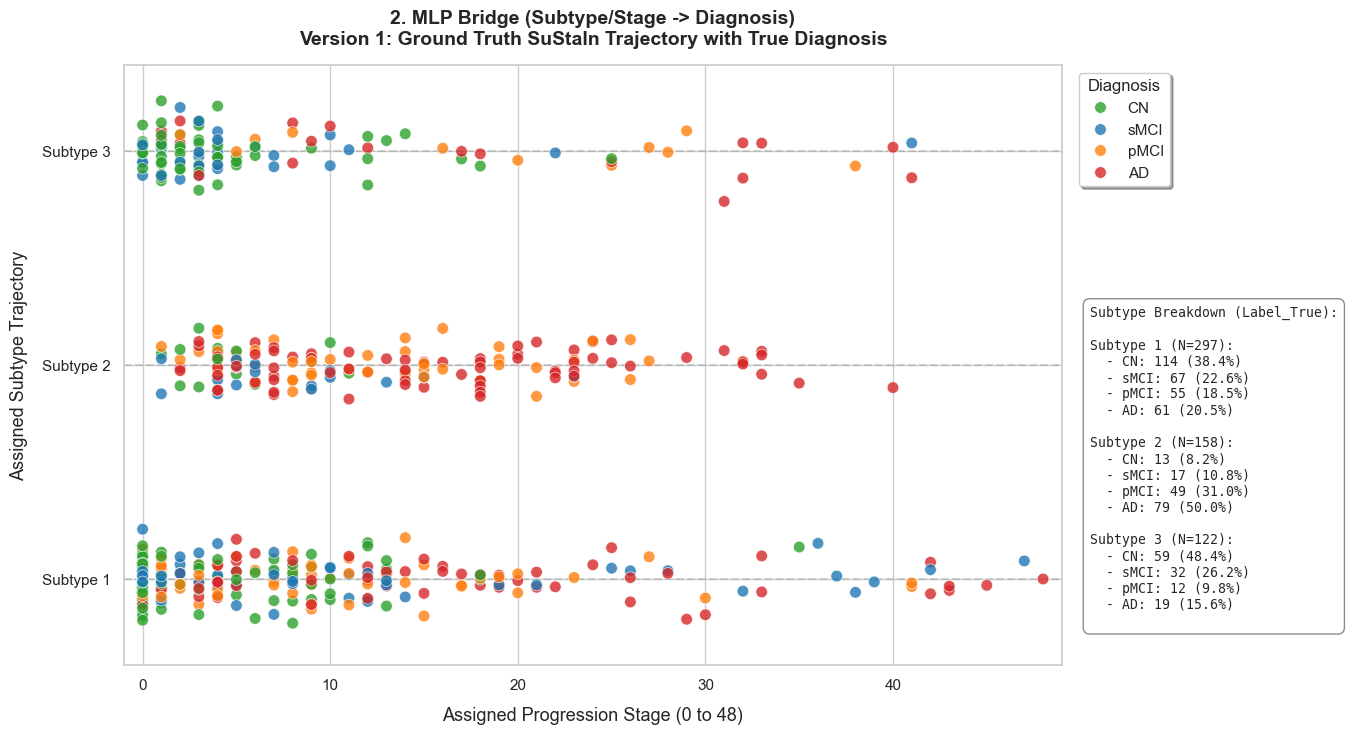

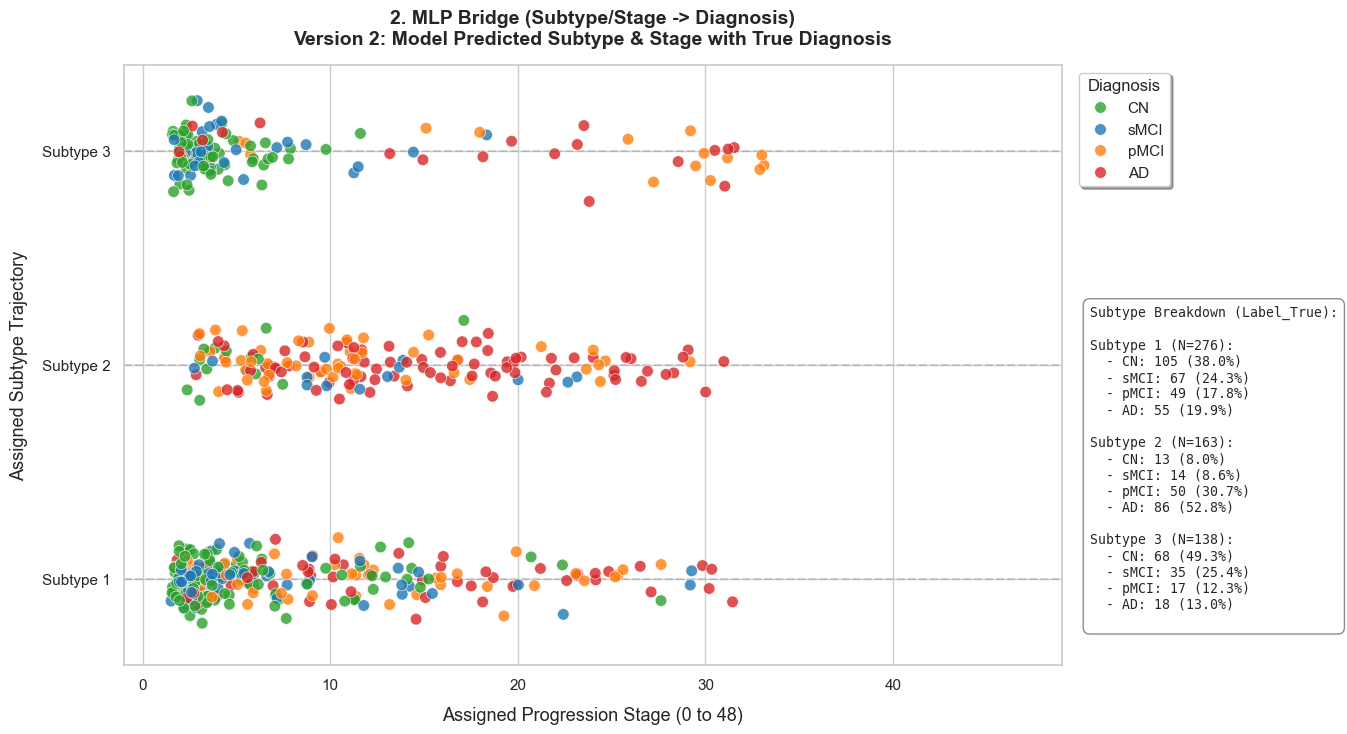

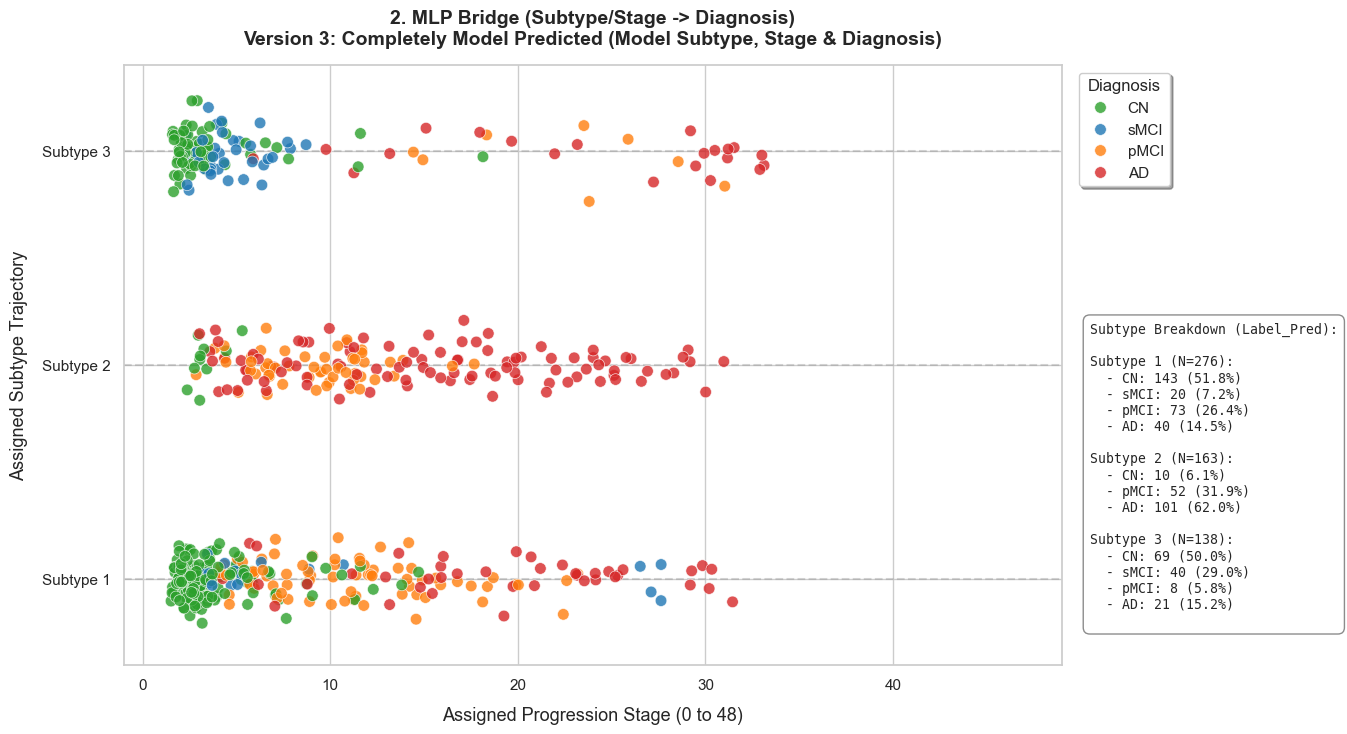


  TRAJECTORY PLOTS: 3. 4-Head ResNet-18 (Multi-Task Combined)


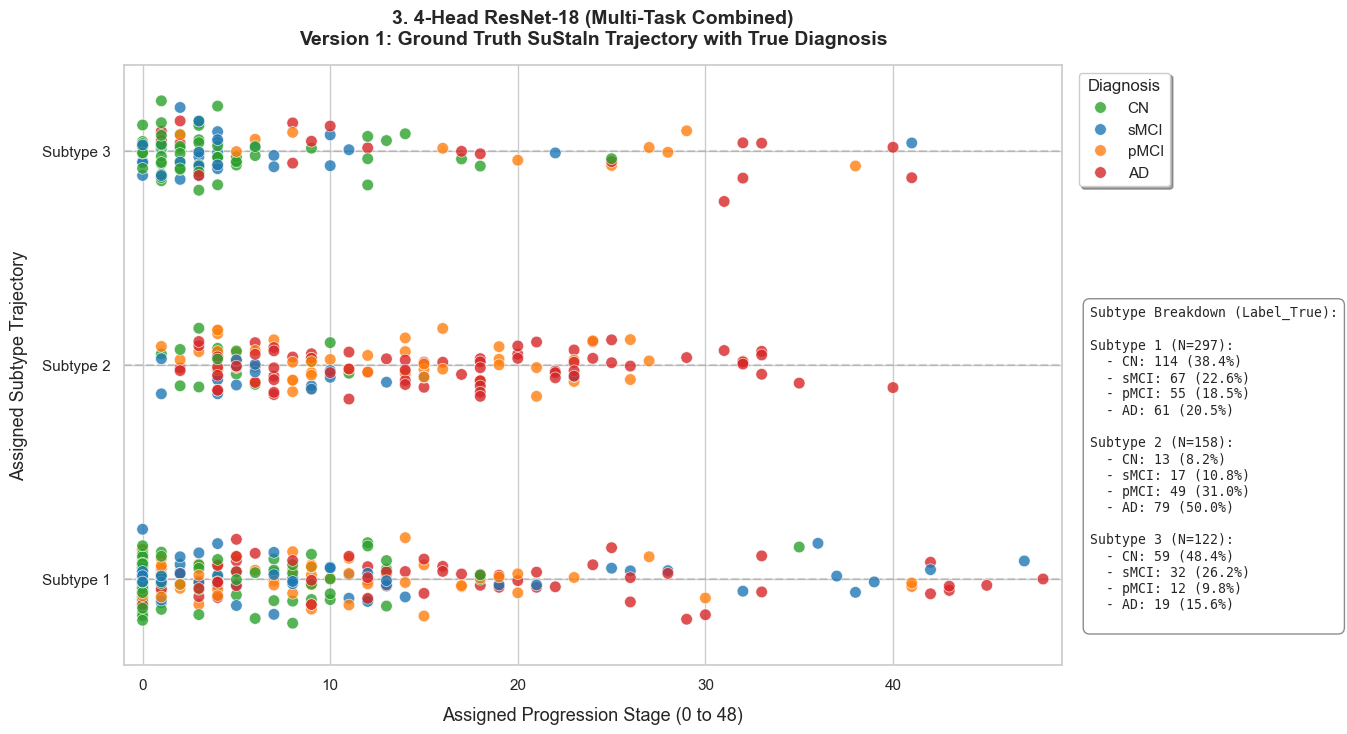

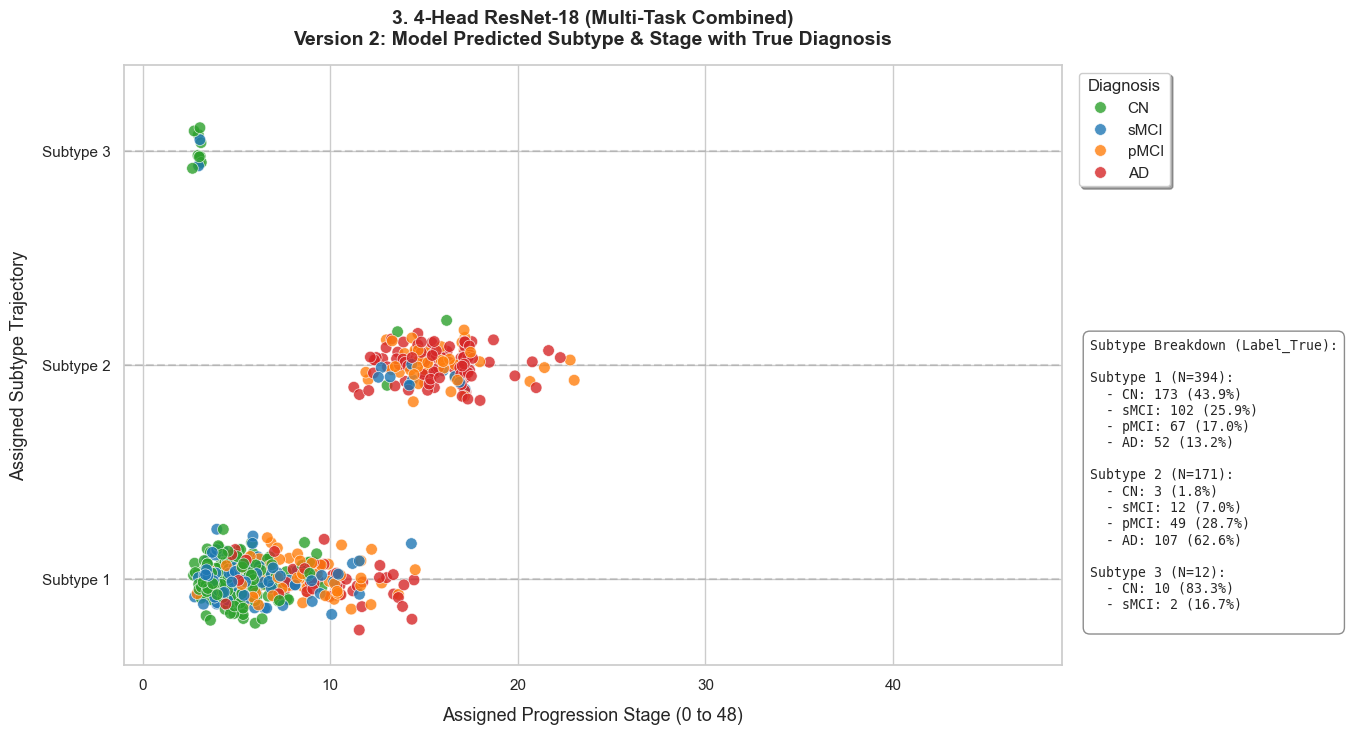

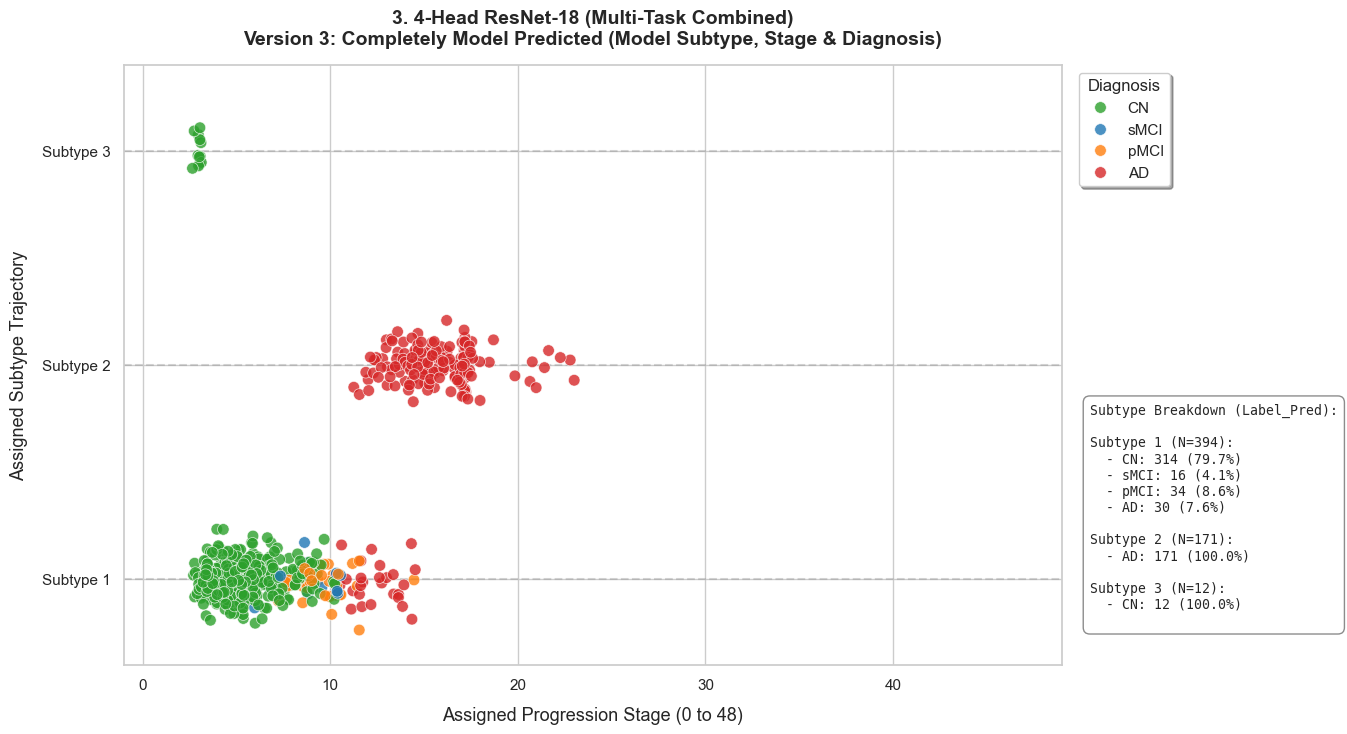

In [5]:
# Loop and plot 3-version trajectories for ALL registered experiments
for exp_key in EXPERIMENT_REGISTRY:
    if exp_key in experiments_data:
        print(f"\n=====================================================================")
        print(f"  TRAJECTORY PLOTS: {EXPERIMENT_REGISTRY[exp_key]['name']}")
        print(f"=====================================================================")
        plot_experiment_trajectories(exp_key)


## 4. Faceted Subtype Distribution Grids (All Experiments)

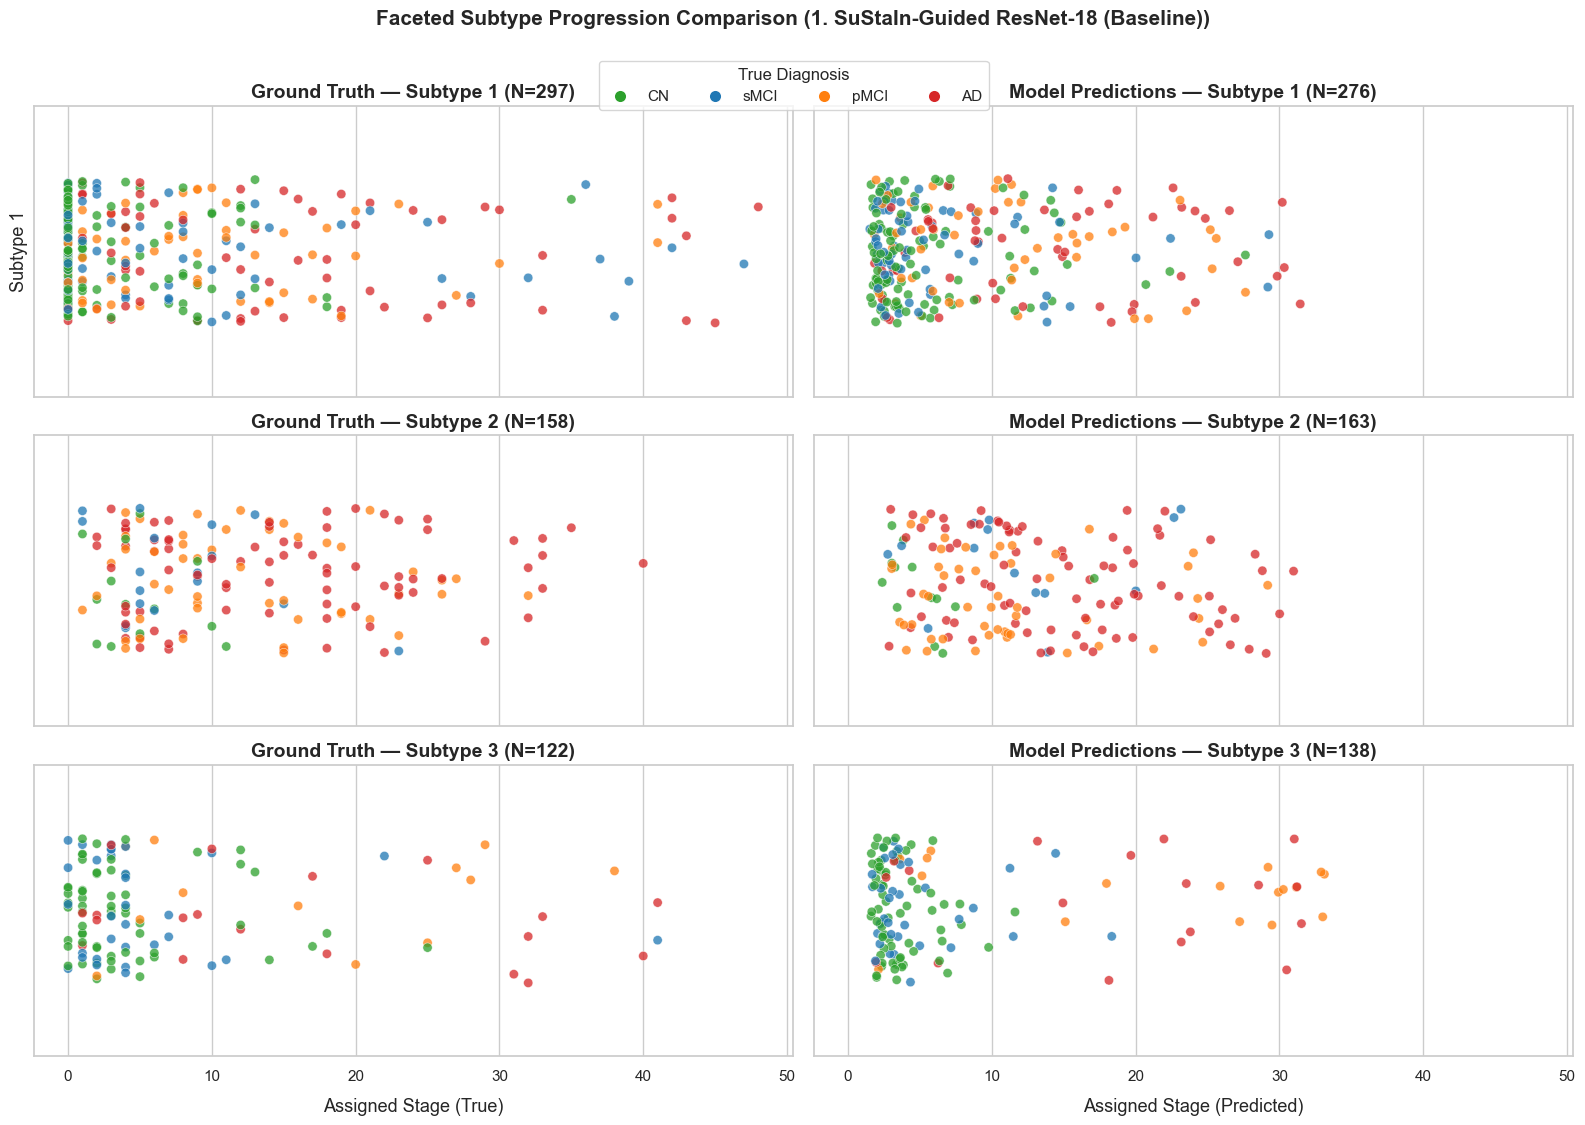

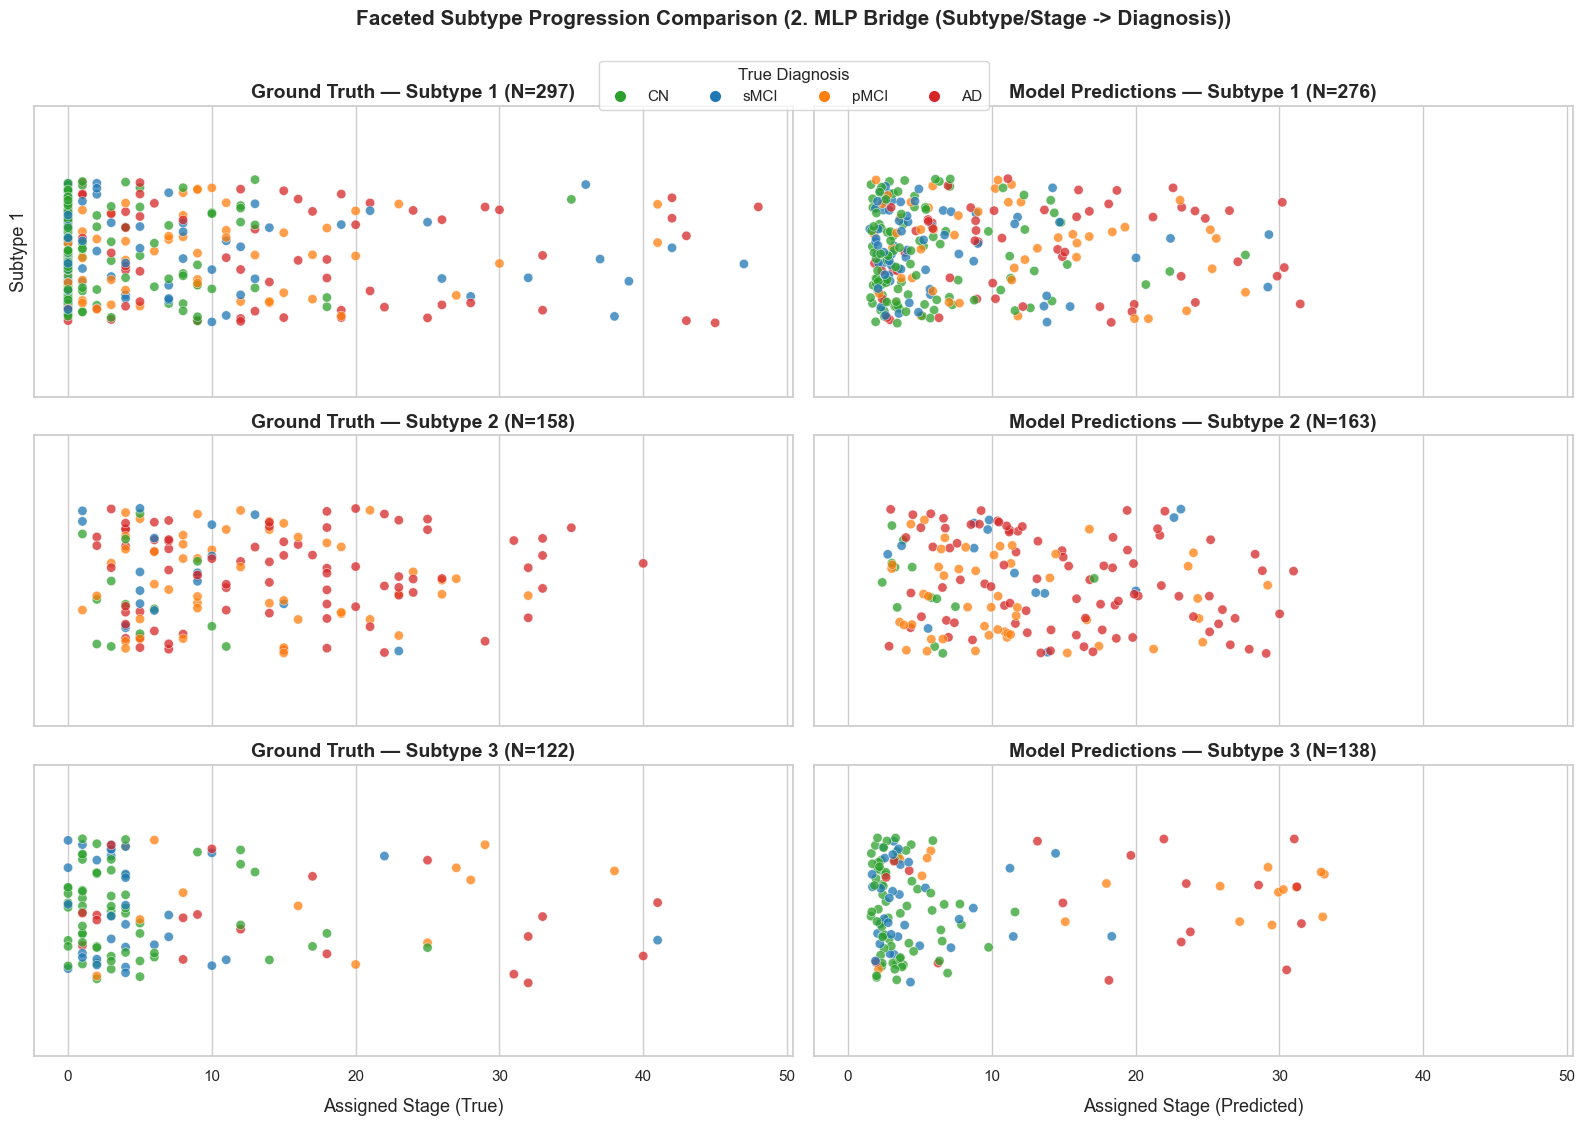

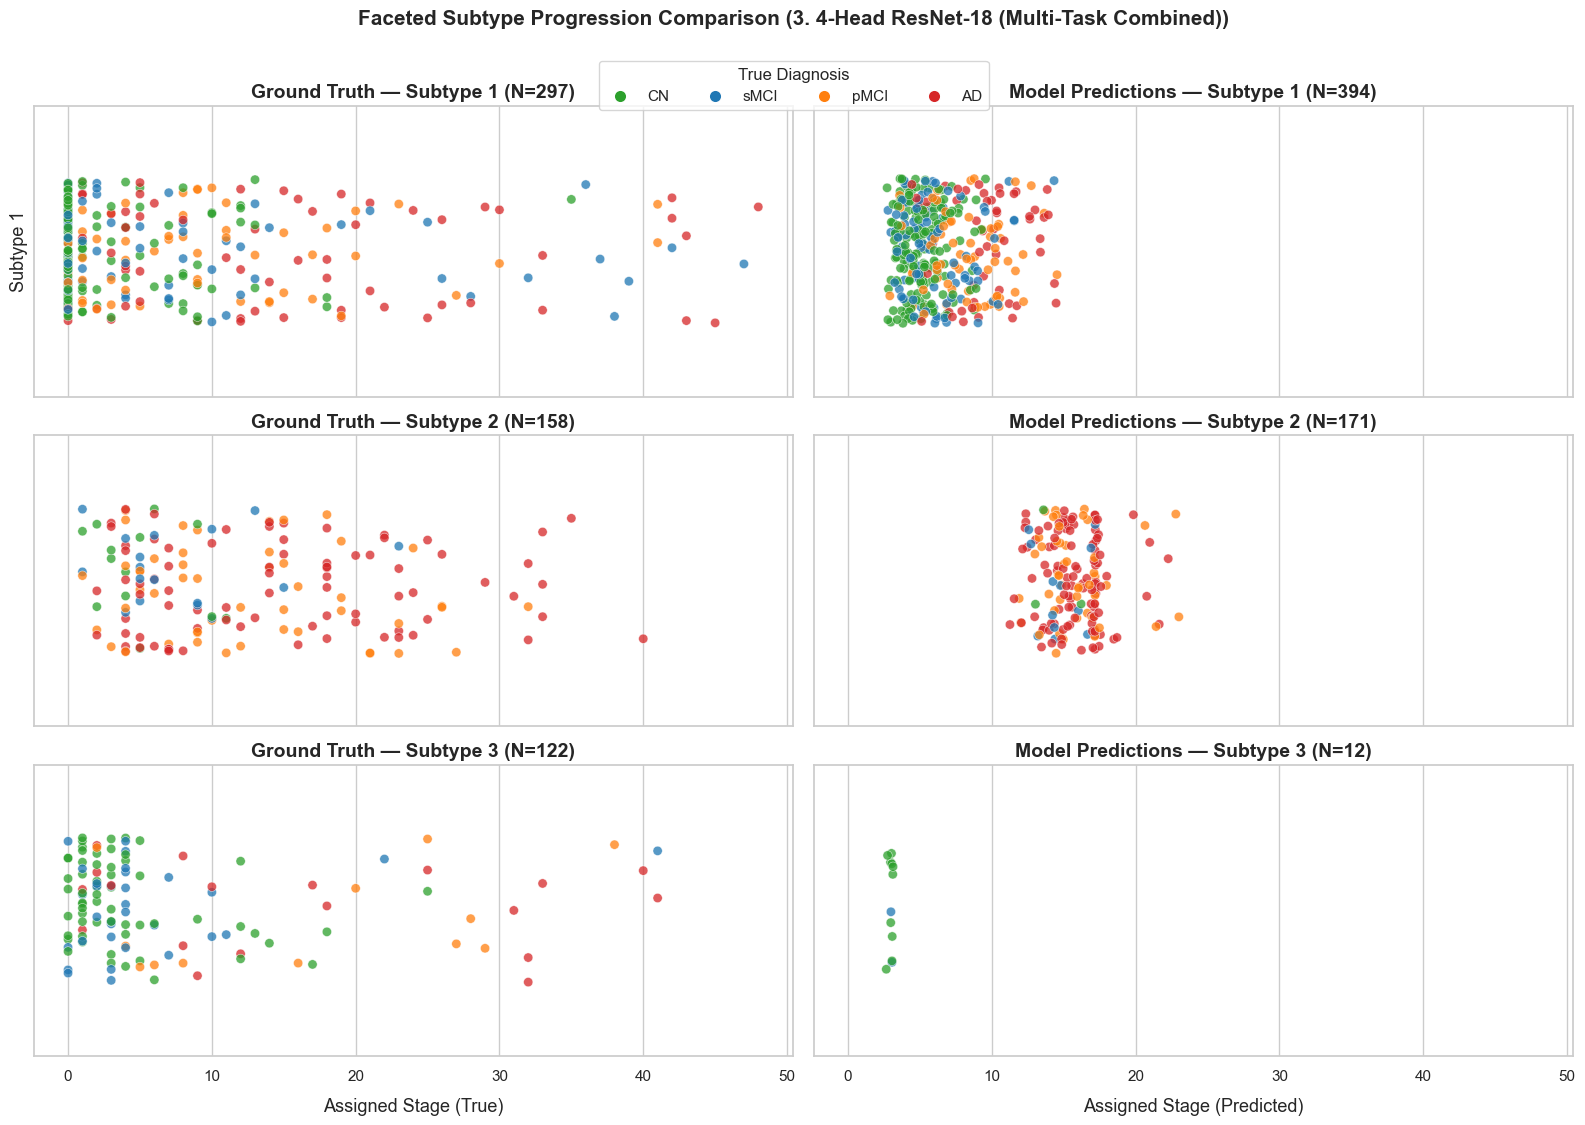

In [6]:
def plot_faceted_subtype_grid(exp_key):
    """
    Plots a clean, faceted 3x2 grid comparing Ground Truth vs Model Predictions
    separately for each SuStaIn subtype.
    """
    df = experiments_data.get(exp_key)
    if df is None:
        return
        
    exp_name = EXPERIMENT_REGISTRY[exp_key]['name']
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex=True, sharey=True)
    rng = np.random.default_rng(42)

    for row_idx, subtype in enumerate([1.0, 2.0, 3.0]):
        df_true_sub = df[df['Assigned_Subtype_True'] == subtype].copy()
        df_pred_sub = df[df['Assigned_Subtype_Pred'] == subtype].copy()

        df_true_sub['Jitter'] = rng.uniform(-0.25, 0.25, size=len(df_true_sub))
        df_pred_sub['Jitter'] = rng.uniform(-0.25, 0.25, size=len(df_pred_sub))

        # Col 0: Ground Truth
        ax_true = axes[row_idx, 0]
        sns.scatterplot(
            data=df_true_sub, x='Assigned_Stage_True', y='Jitter', hue='Label_True',
            hue_order=LABEL_ORDER, palette=PALETTE, alpha=0.75, s=45, edgecolor='w', linewidth=0.4, ax=ax_true, legend=False
        )
        ax_true.set_title(f"Ground Truth — Subtype {int(subtype)} (N={len(df_true_sub)})", weight='bold')
        ax_true.set_ylabel(f"Subtype {int(subtype)}")
        ax_true.set_ylim(-0.5, 0.5)
        ax_true.set_yticks([])
        
        # Col 1: Model Predictions
        ax_pred = axes[row_idx, 1]
        sns.scatterplot(
            data=df_pred_sub, x='Assigned_Stage_Pred', y='Jitter', hue='Label_True',
            hue_order=LABEL_ORDER, palette=PALETTE, alpha=0.75, s=45, edgecolor='w', linewidth=0.4, ax=ax_pred, legend=False
        )
        ax_pred.set_title(f"Model Predictions — Subtype {int(subtype)} (N={len(df_pred_sub)})", weight='bold')
        ax_pred.set_ylim(-0.5, 0.5)
        ax_pred.set_yticks([])

    axes[2, 0].set_xlabel('Assigned Stage (True)', labelpad=10)
    axes[2, 1].set_xlabel('Assigned Stage (Predicted)', labelpad=10)

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE[lbl], markersize=9) for lbl in LABEL_ORDER]
    fig.legend(handles, LABEL_ORDER, title='True Diagnosis', loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=True)

    plt.suptitle(f"Faceted Subtype Progression Comparison ({exp_name})", fontsize=15, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Loop and plot faceted subtype grids for ALL registered experiments
for exp_key in EXPERIMENT_REGISTRY:
    if exp_key in experiments_data:
        plot_faceted_subtype_grid(exp_key)


## 5. Fold-by-Fold Cross-Validation Trajectory Analysis (All Experiments)

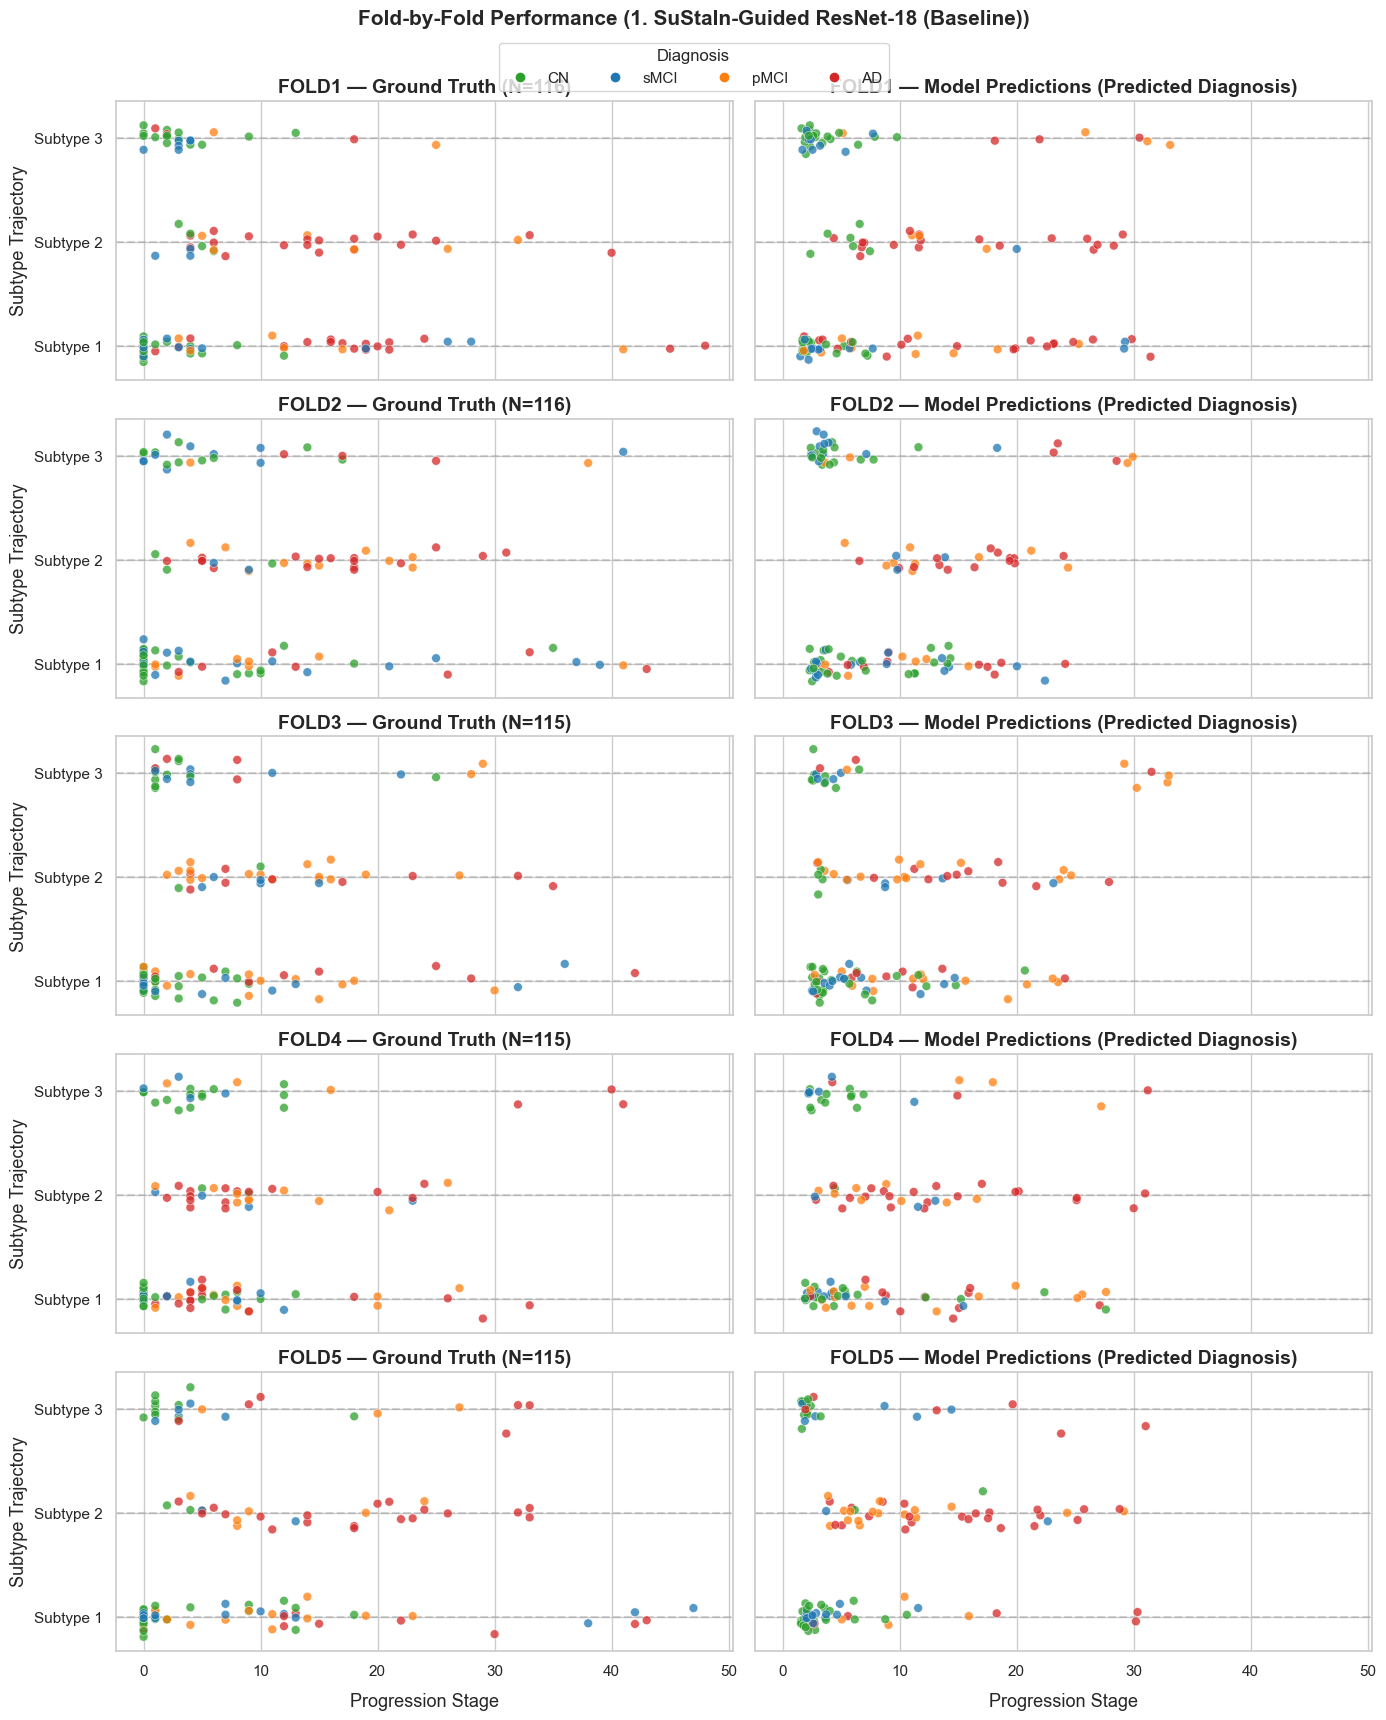

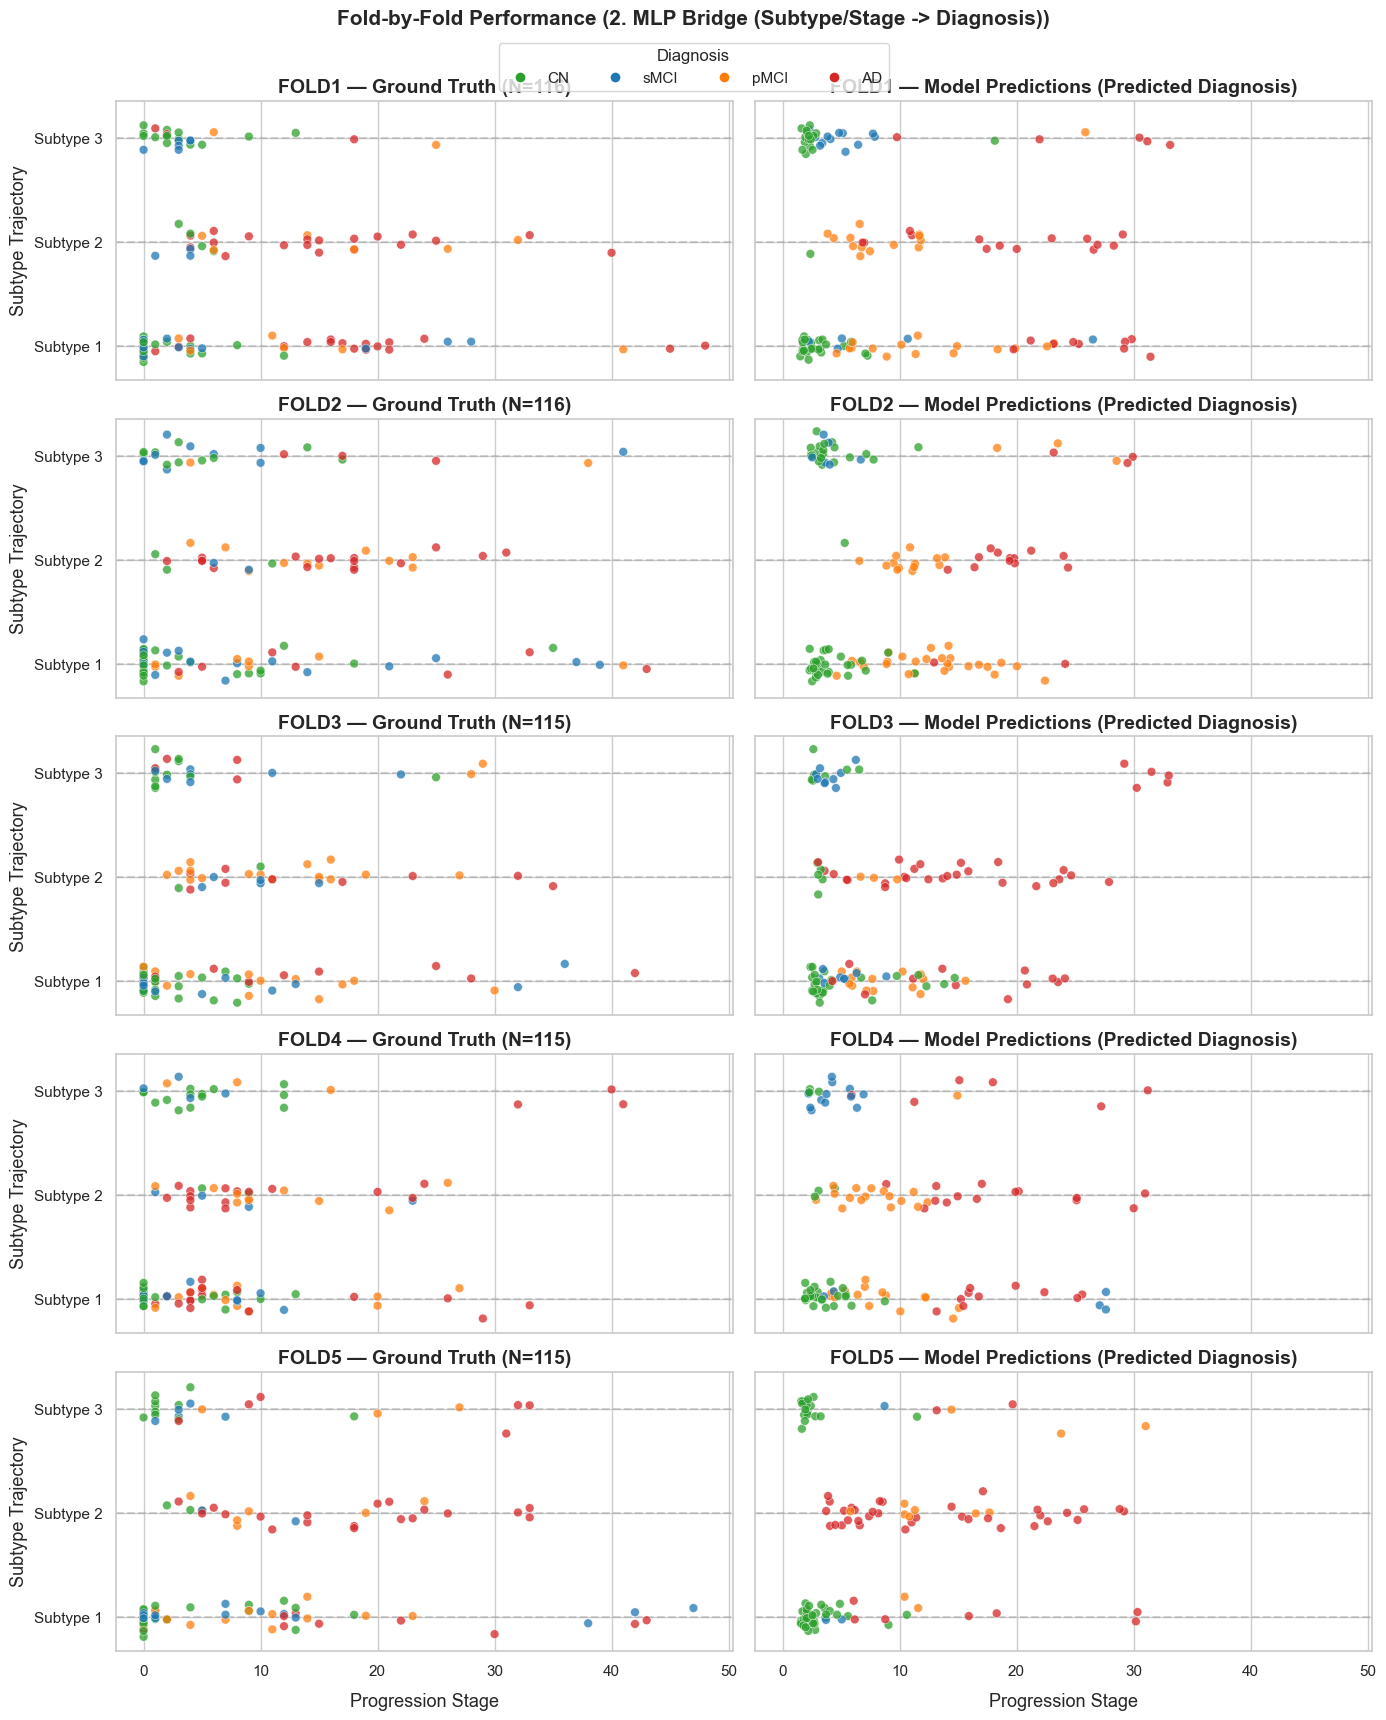

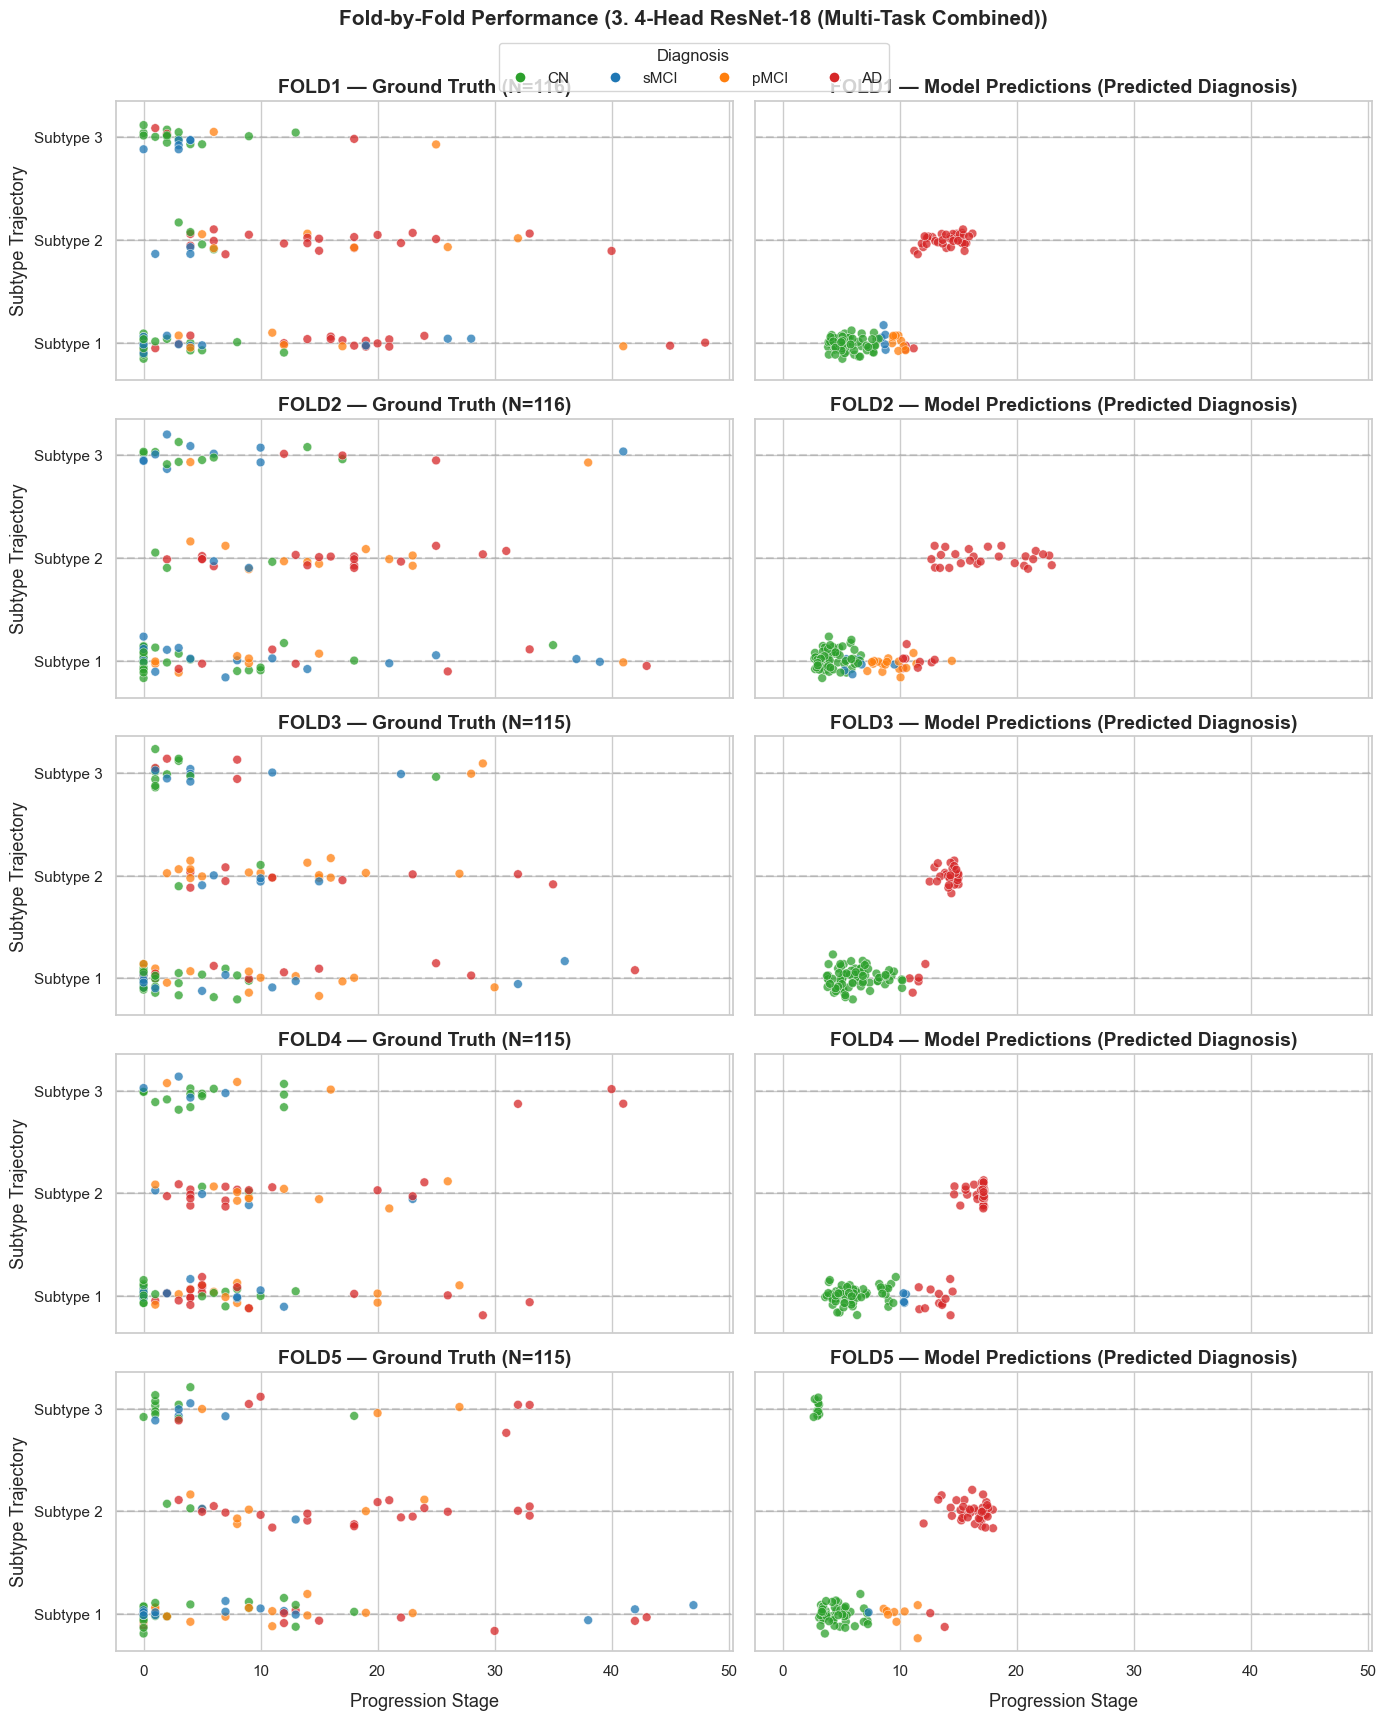

In [7]:
def plot_fold_trajectories(exp_key, color_by_pred_label=False):
    """
    Plots comparative SuStaIn trajectories (Subtype vs Stage) side-by-side per fold.
    If color_by_pred_label=True, colors right column by predicted clinical diagnosis.
    """
    df = experiments_data.get(exp_key)
    if df is None or 'Test_Fold' not in df.columns:
        print(f"Skipping fold plot for '{exp_key}' (No Test_Fold column found).")
        return

    df = df.dropna(subset=['Test_Fold'])
    unique_folds = sorted(df['Test_Fold'].unique())
    n_folds = len(unique_folds)
    
    if n_folds == 0:
        return

    fig, axes = plt.subplots(n_folds, 2, figsize=(14, 3.4 * n_folds), sharex=True, sharey=True)
    if n_folds == 1:
        axes = np.array([axes])

    rng = np.random.default_rng(42)

    for idx, fold_name in enumerate(unique_folds):
        df_fold = df[df['Test_Fold'] == fold_name].copy()
        
        jitter = rng.normal(loc=0.0, scale=0.08, size=len(df_fold))
        df_fold['Subtype_True_Jittered'] = df_fold['Assigned_Subtype_True'] + jitter
        df_fold['Subtype_Pred_Jittered'] = df_fold['Assigned_Subtype_Pred'] + jitter

        # Col 0: Ground Truth
        ax_true = axes[idx, 0]
        for st in [1.0, 2.0, 3.0]:
            ax_true.axhline(y=st, color='gray', linestyle='--', alpha=0.3, zorder=1)
            
        sns.scatterplot(
            data=df_fold, x='Assigned_Stage_True', y='Subtype_True_Jittered', hue='Label_True',
            hue_order=LABEL_ORDER, palette=PALETTE, alpha=0.75, s=40, edgecolor='w', linewidth=0.4, ax=ax_true, legend=False
        )
        ax_true.set_title(f"{fold_name.upper()} — Ground Truth (N={len(df_fold)})", weight='bold')
        ax_true.set_ylabel('Subtype Trajectory')
        ax_true.set_yticks([1.0, 2.0, 3.0])
        ax_true.set_yticklabels(['Subtype 1', 'Subtype 2', 'Subtype 3'])

        # Col 1: Model Predictions
        ax_pred = axes[idx, 1]
        for st in [1.0, 2.0, 3.0]:
            ax_pred.axhline(y=st, color='gray', linestyle='--', alpha=0.3, zorder=1)
            
        pred_label_col = 'Label_Pred' if (color_by_pred_label and df_fold['Label_Pred'].notna().any()) else 'Label_True'
        pred_title_suffix = 'Predicted Diagnosis' if color_by_pred_label else 'True Diagnosis'
        
        sns.scatterplot(
            data=df_fold, x='Assigned_Stage_Pred', y='Subtype_Pred_Jittered', hue=pred_label_col,
            hue_order=LABEL_ORDER, palette=PALETTE, alpha=0.75, s=40, edgecolor='w', linewidth=0.4, ax=ax_pred, legend=False
        )
        ax_pred.set_title(f"{fold_name.upper()} — Model Predictions ({pred_title_suffix})", weight='bold')

    axes[-1, 0].set_xlabel('Progression Stage', labelpad=10)
    axes[-1, 1].set_xlabel('Progression Stage', labelpad=10)

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE[lbl], markersize=8) for lbl in LABEL_ORDER]
    fig.legend(handles, LABEL_ORDER, title='Diagnosis', loc='upper center', bbox_to_anchor=(0.5, 0.995), ncol=4, frameon=True)

    exp_title_str = EXPERIMENT_REGISTRY[exp_key]['name']
    plt.suptitle(f"Fold-by-Fold Performance ({exp_title_str})", fontsize=15, weight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# Loop and plot fold trajectories for ALL registered experiments
for exp_key in EXPERIMENT_REGISTRY:
    if exp_key in experiments_data:
        plot_fold_trajectories(exp_key, color_by_pred_label=True)


## 6. Cross-Experiment Diagnosis Confusion Matrices

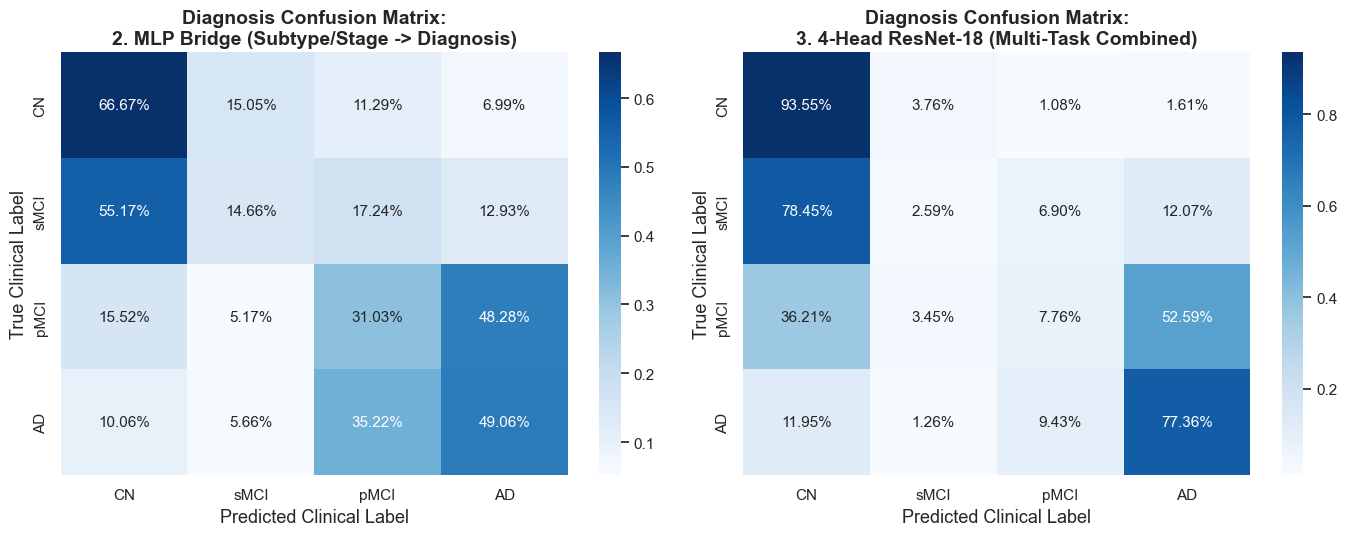

In [8]:
# Side-by-Side Confusion Matrices for Clinical Diagnosis Head Across All Relevant Experiments
diag_experiments = [k for k in EXPERIMENT_REGISTRY if k in experiments_data and experiments_data[k]['Label_Pred'].notna().any()]

if len(diag_experiments) > 0:
    fig, axes = plt.subplots(1, len(diag_experiments), figsize=(7 * len(diag_experiments), 5.5))
    if len(diag_experiments) == 1:
        axes = [axes]
        
    for idx, exp_key in enumerate(diag_experiments):
        df_exp = experiments_data[exp_key]
        cm_norm = confusion_matrix(df_exp['Label_True'], df_exp['Label_Pred'], labels=LABEL_ORDER, normalize='true')
        
        exp_title = EXPERIMENT_REGISTRY[exp_key]['name']
        sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=axes[idx])
        axes[idx].set_title(f"Diagnosis Confusion Matrix:\n{exp_title}", weight='bold')
        axes[idx].set_xlabel('Predicted Clinical Label')
        axes[idx].set_ylabel('True Clinical Label')
        
    plt.tight_layout()
    plt.show()
